# Cleaning and Target Engineering

This notebook transforms the raw FinAccess 2021 survey dataset into a clean, leakage-controlled dataset for analysis and modeling.

The main goal is to safely create the financial exclusion target variable and separate variables into:

1. target-engineering variables
2. unsafe leakage variables
3. administrative/ID variables
4. safe predictor variables

This notebook does not train models. Its purpose is to prepare a trustworthy modeling dataset for EDA, subgroup analysis, and machine learning.

In [1]:
import pandas as pd
import numpy as np
import json
from pathlib import Path

In [2]:
BASE_DIR = Path("..")

RAW_DATA_PATH = BASE_DIR / "Data" / "Raw" / "finaccess_2021_microdata.xlsx"
PROCESSED_DIR = BASE_DIR / "Data" / "Processed"
ARTIFACTS_DIR = BASE_DIR / "artifacts" / "metrics"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

## Load Raw Data

We reload the raw dataset instead of depending on objects from Data Understanding Notebook. This keeps the notebook reproducible and allows it to run independently.

In [3]:
df = pd.read_excel(RAW_DATA_PATH, sheet_name="Dataset")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 22024
Columns: 2332


## Target Engineering

The target variable represents whether a respondent is financially excluded.

Based on data understanding Notebook, the column `excluded_informal_banked2022` contains three financial access categories:

- Banked
- Other Formal
- Excluded

For the first modeling version, this project uses binary classification:

- 1 = financially excluded
- 0 = not financially excluded

`Banked` and `Other Formal` are grouped as not excluded because they indicate some form of formal financial access.

In [4]:
target_source_col = "excluded_informal_banked2022"

df["financially_excluded"] = df[target_source_col].map({
    "Excluded": 1,
    "Banked": 0,
    "Other Formal": 0
})

In [5]:
#validate target
df["financially_excluded"].value_counts(dropna=False)

financially_excluded
0    17430
1     4594
Name: count, dtype: int64

In [6]:
target_distribution = (
    df["financially_excluded"]
    .value_counts(normalize=True, dropna=False)
    .mul(100)
    .round(2)
    .reset_index()
)

target_distribution.columns = ["financially_excluded", "percentage"]
target_distribution

,financially_excluded,percentage
0,0,79.14
1,1,20.86


In [7]:
target_distribution.to_csv(
    ARTIFACTS_DIR / "02_target_distribution.csv",
    index=False
)

The target is imbalanced. Financially excluded respondents are the minority class.

This means accuracy alone will not be enough during modeling. Later notebooks should prioritize recall, precision, F1-score, ROC-AUC, and confusion matrix interpretation.

## Target Engineering Columns

Some variables are useful for defining or validating the target, but they should not be used as predictors.

If a model uses the same variables that define financial exclusion, it may produce artificially high performance.

In [8]:
target_engineering_cols = [
    "excluded_informal_banked2022"
]

## Leakage Review

Target leakage happens when the model sees information that directly reveals the answer.

In this project, leakage risk is high because financial exclusion is defined using financial access. Variables related to bank usage, SACCO usage, mobile money registration, insurance, formal access, informal access, loans, savings, and credit must be reviewed carefully.

In [9]:
leakage_keywords = [
    "banked", "excluded", "formal", "informal",
    "bank", "sacco", "insurance", "pension",
    "mobile", "money", "loan", "credit", "saving",
    "borrow"
]

potential_leakage_cols = [
    col for col in df.columns
    if any(keyword in col.lower() for keyword in leakage_keywords)
]

len(potential_leakage_cols)

104

In [10]:
potential_leakage_cols[:100]

['savings_usage',
 'savings_formal',
 'savings_informal',
 'savings_excluded',
 'loan_usage',
 'loan_formal',
 'loan_informal',
 'loan_formal_2',
 'loan_mbanking_2',
 'loan_fuliza_2',
 'loan_app_2',
 'savings_mbanking_2',
 'savings_mmoney_2',
 'savings_formal2',
 'tot_saving',
 'mobile',
 'bank_usage',
 'bank_usage1',
 'bank_usage3',
 'bank_usage2',
 'insurance_usage',
 'insurance_usage2',
 'insurance_usage1',
 'pension_usage',
 'pension_usage_2',
 'mobile_bank_usage',
 'mobile_money_usage',
 'digital_app_loan',
 'formal_digital_sav',
 'formal_non_digital_sav',
 'formal_digital_loan',
 'formal_non_digital_loan',
 'tot_formal_digit_loan_sav',
 'tot_formal_non_digit_loan_sav',
 'sacco_usage',
 'formal_prudential',
 'formal_non_prudential',
 'formal_registered',
 'formal',
 'formal_other',
 'informal',
 'Traditional_bank_users',
 'Commercial_Bank_users',
 'Post_bank_users',
 'Digital_credit',
 'mobile_access',
 'mobile_own',
 'formal_service_use',
 'formal_fullservice_use',
 'mobile_money

In [11]:
leakage_review = pd.DataFrame({
    "column": potential_leakage_cols,
    "reason": "keyword_match_financial_access",
    "decision": "review_before_modeling"
})

leakage_review.to_csv(
    ARTIFACTS_DIR / "02_leakage_review_columns.csv",
    index=False
)

In [12]:
definite_leakage_cols = [
    "excluded_informal_banked2022",
    "bank_usage",
    "mobile_money_usage",
    "formal",
    "informal",
    ...
]

## Leakage Decision Framework

Potential leakage variables were reviewed based on whether they directly reveal financial access status.

Variables directly describing:
- bank account ownership
- mobile money usage
- SACCO participation
- formal access
- exclusion categories

are considered unsafe for the first structural-risk model because they strongly overlap with the target definition.

These variables may later be used in a separate operational inclusion model, but they are excluded from the structural-risk modeling dataset.

## Administrative and ID Columns

ID columns help identify records, interviews, households, or survey clusters. They are not useful for predicting future financial exclusion risk.

Using them can cause overfitting because the model may memorize records instead of learning general risk patterns.

In [13]:
id_like_keywords = [
    "id", "key", "serial", "cluster", "hhno", "interview"
]

id_like_cols = [
    col for col in df.columns
    if any(keyword in col.lower() for keyword in id_like_keywords)
]

id_like_cols

['Serial Number',
 'ClusterNo',
 'HHNo',
 'interview__key',
 'interview__id',
 'E1iD',
 'E1iiD',
 'E1iiiD',
 'E1viD',
 'E1viiD',
 'E1viiiD',
 'cluster_type',
 'Classification_A_Liquidity',
 'paidlate',
 'didnotdothis',
 'Classification_A_Liquidity_new']

In [14]:
admin_cols = [
    "Serial Number",
    "ClusterNo",
    "HHNo",
    "interview__key",
    "interview__id"
]

admin_cols = [col for col in admin_cols if col in df.columns]
admin_cols

['Serial Number', 'ClusterNo', 'HHNo', 'interview__key', 'interview__id']

## Safe Predictor Selection

This project begins with a structural-risk modeling dataset.

The goal is to predict financial exclusion risk using demographic, geographic, and socioeconomic characteristics instead of directly using financial service ownership variables.

This creates a cleaner and more policy-relevant model.

In [15]:
candidate_predictor_cols = [
    "County",   # geography
    "A9",       # rural/urban
    "A10i",     # sex
    "A19",      # age
    "A21",      # education completed
    "A22",      # marital status
    "adults"    # household adult composition
]

candidate_predictor_cols = [
    col for col in candidate_predictor_cols
    if col in df.columns
]

candidate_predictor_cols

['County', 'A9', 'A10i', 'A19', 'A21', 'A22', 'adults']

In [16]:
modeling_cols = candidate_predictor_cols + ["financially_excluded"]

model_df = df[modeling_cols].copy()

model_df.head()

,County,A9,A10i,A19,A21,A22,adults,financially_excluded
0,Trans Nzoia,Rural,Female,59,Completed technical training after secondary s...,Widowed,1 adult Household,0
1,Busia,Rural,Female,43,Completed technical training after secondary s...,Married/Living with partner,>1 adult Household,0
2,Machakos,Rural,Male,72,"""Some primary """,Divorced/separated,1 adult Household,1
3,Kisumu,Rural,Male,22,"""Primary completed""",Single/Never Married,>1 adult Household,0
4,Nyeri,Urban,Male,36,"""Primary completed""",Married/Living with partner,>1 adult Household,0


In [17]:
model_df.isna().mean().mul(100).round(2).sort_values(ascending=False)

County                  0.0
A9                      0.0
A10i                    0.0
A19                     0.0
A21                     0.0
A22                     0.0
adults                  0.0
financially_excluded    0.0
dtype: float64

## Missing Value Strategy

Survey datasets contain different types of missingness.

A missing value may indicate:
- the question was not applicable
- the respondent was skipped due to survey routing
- the respondent refused to answer
- the value was unknown

Because of this, missing values are not automatically treated as ordinary missing data.

For the first structural-risk modeling dataset, the selected core variables contain minimal missingness. However, later feature expansion notebooks may require:
- explicit missing-category encoding
- imputation
- structural missingness indicators
- variable-specific cleaning rules

## Basic Feature Engineering

Feature engineering creates more meaningful predictors from raw survey variables.

For this first version, we create simple interpretable features such as youth status and rural youth status.

In [18]:
if "A19" in model_df.columns:
    model_df["age"] = pd.to_numeric(model_df["A19"], errors="coerce")
    model_df["is_youth"] = np.where(model_df["age"].between(18, 35), 1, 0)

In [19]:
if "A9" in model_df.columns and "is_youth" in model_df.columns:
    model_df["is_rural_youth"] = np.where(
        (model_df["A9"].astype(str).str.lower() == "rural") &
        (model_df["is_youth"] == 1),
        1,
        0
    )

## Rename Columns

Raw survey variable names are difficult for stakeholders to understand.

We rename selected variables into readable names while keeping a record of the mapping for reproducibility.

In [20]:
rename_map = {
    "A9": "location_type",
    "A10i": "gender",
    "A19": "raw_age",
    "A21": "education_level",
    "A22": "marital_status"
}

rename_map = {
    old: new for old, new in rename_map.items()
    if old in model_df.columns
}

model_df = model_df.rename(columns=rename_map)

model_df.head()

,County,location_type,gender,raw_age,education_level,marital_status,adults,financially_excluded,age,is_youth,is_rural_youth
0,Trans Nzoia,Rural,Female,59,Completed technical training after secondary s...,Widowed,1 adult Household,0,59,0,0
1,Busia,Rural,Female,43,Completed technical training after secondary s...,Married/Living with partner,>1 adult Household,0,43,0,0
2,Machakos,Rural,Male,72,"""Some primary """,Divorced/separated,1 adult Household,1,72,0,0
3,Kisumu,Rural,Male,22,"""Primary completed""",Single/Never Married,>1 adult Household,0,22,1,1
4,Nyeri,Urban,Male,36,"""Primary completed""",Married/Living with partner,>1 adult Household,0,36,0,0


In [21]:
with open(ARTIFACTS_DIR / "02_column_rename_map.json", "w") as f:
    json.dump(rename_map, f, indent=4)

## Remove Rows Without Target

Rows without a target cannot be used for supervised learning because the model would not know the correct answer during training.

In [22]:
before_rows = model_df.shape[0]

model_df = model_df.dropna(subset=["financially_excluded"])

after_rows = model_df.shape[0]

print("Rows before:", before_rows)
print("Rows after:", after_rows)
print("Rows removed:", before_rows - after_rows)

Rows before: 22024
Rows after: 22024
Rows removed: 0


In [23]:
model_df.to_csv(
    PROCESSED_DIR / "finaccess_2021_modeling_base.csv",
    index=False
)

In [24]:
feature_cols = [
    col for col in model_df.columns
    if col != "financially_excluded"
]

with open(ARTIFACTS_DIR / "02_feature_columns.json", "w") as f:
    json.dump(feature_cols, f, indent=4)

In [25]:
dropped_columns = pd.DataFrame({
    "column": admin_cols + target_engineering_cols + potential_leakage_cols,
    "drop_reason": (
        ["administrative_or_id"] * len(admin_cols) +
        ["target_engineering"] * len(target_engineering_cols) +
        ["potential_leakage"] * len(potential_leakage_cols)
    )
}).drop_duplicates()

dropped_columns.to_csv(
    ARTIFACTS_DIR / "02_dropped_or_review_columns.csv",
    index=False
)

In [26]:
feature_selection_reasoning = pd.DataFrame({
    "feature": [
        "County",
        "location_type",
        "gender",
        "raw_age",
        "education_level",
        "marital_status",
        "adults"
    ],

    "reason": [
        "captures geographic inequality",
        "captures rural/urban vulnerability",
        "captures demographic disparities",
        "captures lifecycle financial vulnerability",
        "captures socioeconomic capability",
        "captures household structure",
        "captures household composition"
    ]
})

feature_selection_reasoning

,feature,reason
0,County,captures geographic inequality
1,location_type,captures rural/urban vulnerability
2,gender,captures demographic disparities
3,raw_age,captures lifecycle financial vulnerability
4,education_level,captures socioeconomic capability
5,marital_status,captures household structure
6,adults,captures household composition


In [27]:
feature_selection_reasoning.to_csv(
    ARTIFACTS_DIR / "02_feature_selection_reasoning.csv",
    index=False
)

# Structural-Risk Modeling Philosophy

This project intentionally begins with a structural-risk modeling approach rather than a direct financial access prediction approach.

The first model focuses on demographic, geographic, and socioeconomic predictors instead of direct financial service ownership variables.

This design choice improves:
- interpretability
- policy relevance
- fairness
- deployment realism
- leakage control

The goal is to identify underlying vulnerability patterns associated with financial exclusion rather than simply detecting whether someone already uses financial products.

In [28]:
categorical_features = [
    "County",
    "location_type",
    "gender",
    "education_level",
    "marital_status",
    "adults"
]

numeric_features = [
    "age",
    "is_youth",
    "is_rural_youth"
]

In [29]:
feature_types = {
    "categorical": categorical_features,
    "numeric": numeric_features
}

with open(ARTIFACTS_DIR / "02_feature_types.json", "w") as f:
    json.dump(feature_types, f, indent=4)

In [30]:
categorical_cols = model_df.select_dtypes(include="object").columns

for col in categorical_cols:
    model_df[col] = (
        model_df[col]
        .astype(str)
        .str.strip()
        .str.replace('"', '', regex=False)
    )

In [31]:
model_df["age"].describe()

count    22024.000000
mean        38.896704
std         17.211553
min         16.000000
25%         26.000000
50%         35.000000
75%         49.000000
max        116.000000
Name: age, dtype: float64

<Axes: >

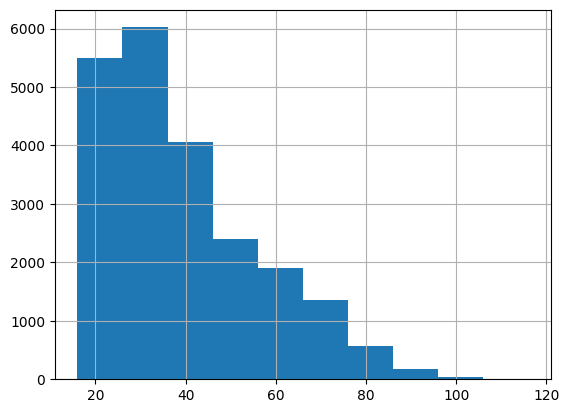

In [32]:
model_df["age"].hist()

In [33]:
model_df[model_df["age"] < 18][
    ["age", "gender", "County", "financially_excluded"]
].head()

,age,gender,County,financially_excluded
17,17,Female,Kericho,1
48,16,Female,Nakuru,1
50,17,Male,Mandera,0
63,17,Female,Machakos,1
106,17,Male,Bomet,1


In [34]:
model_df[model_df["age"] > 100][
    ["age", "gender", "County", "financially_excluded"]
]

,age,gender,County,financially_excluded
2463,101,Male,Kitui,0
2836,116,Male,Kitui,1
5976,111,Female,Embu,0
11439,110,Female,Kericho,1
11709,103,Female,Kitui,0
13609,107,Female,Kirinyaga,0
17103,113,Female,Murang'a,0


## Defining the Modeling Population

The project focuses on predicting financial exclusion risk among adults.

During age validation, a small number of respondents were found:
- below 18 years
- above 100 years

Although these values may not necessarily be errors, respondents outside the range 18–100 were excluded from the first modeling dataset.

This decision was made to:
- align the project with adult financial inclusion analysis
- improve deployment realism
- reduce potential demographic noise
- create a more interpretable modeling population

In [35]:
before_rows = model_df.shape[0]

model_df = model_df[
    (model_df["age"] >= 18) &
    (model_df["age"] <= 100)
]

after_rows = model_df.shape[0]

print("Rows before:", before_rows)
print("Rows after:", after_rows)
print("Rows removed:", before_rows - after_rows)

Rows before: 22024
Rows after: 20902
Rows removed: 1122


In [36]:
model_df["age"].describe()

count    20902.000000
mean        40.067793
std         16.803774
min         18.000000
25%         27.000000
50%         36.000000
75%         50.000000
max        100.000000
Name: age, dtype: float64

In [37]:
#drop raw_age as we have age and age groups
model_df = model_df.drop(columns=["raw_age"])

In [38]:
model_df["financially_excluded"].value_counts(normalize=True)

financially_excluded
0    0.824323
1    0.175677
Name: proportion, dtype: float64

## Impact of Age-Based Population Filtering

After restricting the modeling population to respondents aged 18–100:

- 1,122 records were removed
- the dataset size reduced from 22,024 to 20,902 respondents
- the financial exclusion rate decreased from approximately 20.9% to 17.6%

This suggests that respondents outside the 18–100 range were more likely to be financially excluded.

The filtered population is considered more appropriate for modeling adult financial inclusion risk because:
- most regulated financial services target adults
- deployment realism improves
- demographic consistency improves
- policy interpretation becomes more reliable

# Post-Cleaning Validation

After cleaning and population filtering, the modeling dataset was revalidated to ensure:

- valid age ranges
- consistent target creation
- stable class distributions
- no missing target values
- reasonable demographic structure

This step helps confirm that preprocessing decisions did not unintentionally damage the dataset.

In [39]:
print(model_df.shape)

(20902, 10)


In [40]:
model_df.duplicated().sum()

np.int64(2944)

In [41]:
df["interview__id"].duplicated().sum()

np.int64(0)

## Duplicate Validation Results

The reduced modeling dataset contained repeated rows after feature selection.

However, duplicate checks on the original respondent identifiers showed:

- `interview__id` duplicates = 0

This confirms that the survey respondents themselves are unique.

Therefore, the repeated rows in the reduced modeling dataset represent different respondents who share identical demographic and geographic feature combinations rather than duplicated survey entries.

The rows were retained to preserve the true population structure of the dataset.

## Save Final Validated Modeling Dataset

After completing:
- target engineering
- leakage review
- feature selection
- demographic validation
- population filtering
- feature engineering
- post-cleaning validation

the final modeling dataset is saved for downstream EDA and modeling notebooks.

In [42]:
model_df.to_csv(
    PROCESSED_DIR / "finaccess_2021_modeling_base.csv",
    index=False
)

## Notebook 02 Summary

This notebook created the first clean modeling base dataset.

Key decisions:

1. The binary target `financially_excluded` was created from `excluded_informal_banked2022`.
2. `Excluded` was mapped to 1.
3. `Banked` and `Other Formal` were mapped to 0.
4. Administrative columns were identified for exclusion.
5. Potential leakage variables were flagged for review.
6. A small structural-risk feature set was selected for the first modeling base.
7. Basic engineered features were created, including youth and rural youth indicators.
8. Processed data and reproducibility artifacts were saved.
